In [51]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
from sklearn.preprocessing import LabelEncoder

In [52]:
# Importing the files

# Data consisting of the purchases of each customer for each date
transactions = pd.read_csv("data/transactions.csv")
# Detailed metadata for each article_id available for purchase
articles = pd.read_csv("data/articles.csv")
# Metadata for each customer_id in dataset
customers = pd.read_csv("data/customers.csv")

EDA


#### Customers.csv


In [53]:
customers.head()

,customer_id,FN,Active,club_member_status,fashion_news_frequency,age,postal_code
0,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,NaN,NaN,ACTIVE,NONE,49.0,52043ee2162cf5aa7ee79974281641c6f11a68d276429a...
1,0000423b00ade91418cceaf3b26c6af3dd342b51fd051e...,NaN,NaN,ACTIVE,NONE,25.0,2973abc54daa8a5f8ccfe9362140c63247c5eee03f1d93...
2,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,NaN,NaN,ACTIVE,NONE,24.0,64f17e6a330a85798e4998f62d0930d14db8db1c054af6...
3,00005ca1c9ed5f5146b52ac8639a40ca9d57aeff4d1bd2...,NaN,NaN,ACTIVE,NONE,54.0,5d36574f52495e81f019b680c843c443bd343d5ca5b1c2...
4,00006413d8573cd20ed7128e53b7b13819fe5cfc2d801f...,1.0,1.0,ACTIVE,Regularly,52.0,25fa5ddee9aac01b35208d01736e57942317d756b32ddd...


In [54]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1371980 entries, 0 to 1371979
Data columns (total 7 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   customer_id             1371980 non-null  object 
 1   FN                      476930 non-null   float64
 2   Active                  464404 non-null   float64
 3   club_member_status      1365918 non-null  object 
 4   fashion_news_frequency  1355969 non-null  object 
 5   age                     1356119 non-null  float64
 6   postal_code             1371980 non-null  object 
dtypes: float64(3), object(4)
memory usage: 73.3+ MB


The customers dataset contains demographic and membership-related information about users. Key columns include `customer_id`, `age`, `FN`, `Active`, `club_member_status`, and `fashion_news_frequency`.

- `customer_id` serves as a unique identifier and is used to link with transactions.
- `age` is a numerical feature but contains missing values, which were handled using median imputation. It is important for customer segmentation.
- `FN` and `Active` are binary-like features indicating engagement level; missing values were filled with 0, assuming inactivity.
- `club_member_status` and `fashion_news_frequency` are categorical features that describe customer loyalty and marketing engagement. Missing values were replaced with 'UNKNOWN' and 'NONE' respectively to preserve data.
- The `postal_code` column was removed due to its high cardinality and low usefulness for modeling.

Overall, this dataset provides valuable behavioral and demographic signals but requires careful handling of categorical encoding and missing values.


In [55]:
customers.isnull().sum().sort_values(ascending=False)

Active                    907576
FN                        895050
fashion_news_frequency     16011
age                        15861
club_member_status          6062
customer_id                    0
postal_code                    0
dtype: int64

In [56]:
customers['age'] = customers['age'].fillna(customers['age'].median())                              
customers[['FN', 'Active']] = customers[['FN', 'Active']].fillna(0)                                
customers['club_member_status'] = customers['club_member_status'].fillna('UNKNOWN')                
customers['fashion_news_frequency'] = customers['fashion_news_frequency'].fillna('NONE')
customers.drop(columns=['postal_code'], inplace=True)                                             


C:\Users\admin\AppData\Local\Temp\ipykernel_16072\3995632985.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=customers, x='Active', y='age', palette=palette)
C:\Users\admin\AppData\Local\Temp\ipykernel_16072\3995632985.py:4: UserWarning: The palette list has more values (10) than needed (2), which may not be intended.
  sns.violinplot(data=customers, x='Active', y='age', palette=palette)
C:\Users\admin\AppData\Local\Temp\ipykernel_16072\3995632985.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=customers, x='club_member_status', y='age', palette=palette)
C:\Users\admin\AppData\Local\Temp\ipykernel_16072\3995632985.py:7: UserWarning: The palette list has more values (10

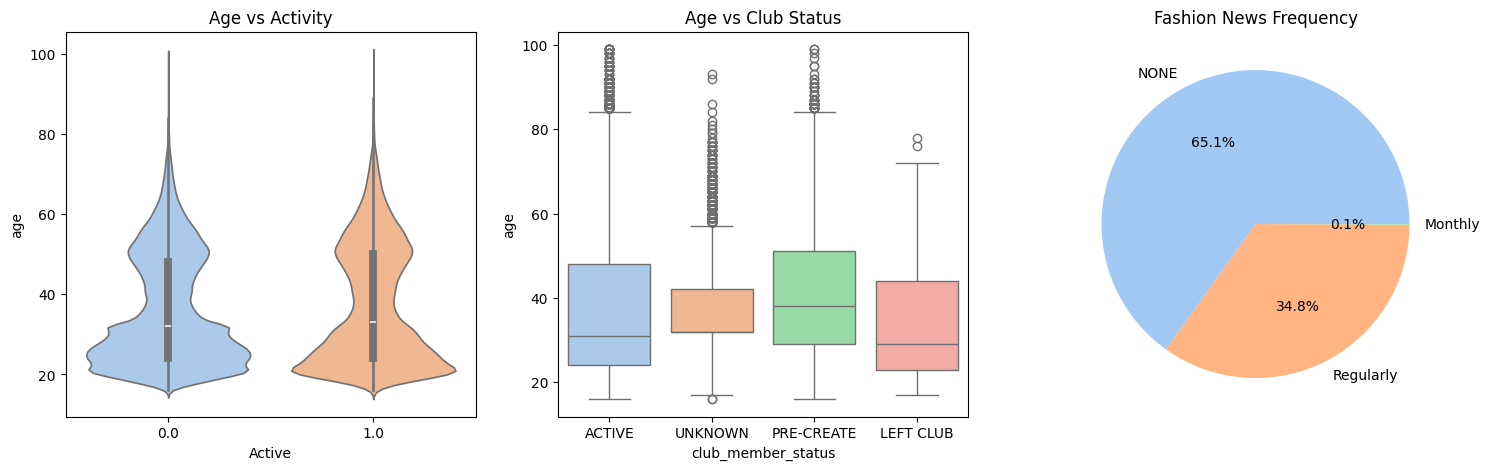

In [57]:
plt.figure(figsize=(18, 5))
palette = sns.color_palette("pastel")
plt.subplot(131).set_title('Age vs Activity')
sns.violinplot(data=customers, x='Active', y='age', palette=palette)

plt.subplot(132).set_title('Age vs Club Status')
sns.boxplot(data=customers, x='club_member_status', y='age', palette=palette)
plt.subplot(133).set_title('Fashion News Frequency')
customers['fashion_news_frequency'].value_counts().plot.pie(autopct='%1.1f%%', colors=palette, ylabel='');

During the preprocessing stage of the Customers dataset, missing values in the age column were imputed with the median, while null entries in the FN and Active columns were filled with zeros, and non-informative features like postal codes were dropped. Categorical variables, including club member status and fashion news frequency, were transformed into numerical formats using LabelEncoder to ensure model compatibility. Visual analysis indicates that the customer base is primarily concentrated in the middle-age demographic, with activity levels showing a relatively balanced distribution across different ages. The finding that approximately 65% of customers do not regularly follow fashion news suggests a need to re-evaluate the efficiency of this communication channel, while age variations across membership statuses point toward opportunities for age-specific loyalty programs. With both technical refinements and exploratory visualizations complete, the dataset is now fully prepared for the final merge operation that will form the basis of the predictive modeling phase.

#### articles.csv

In [58]:
articles.head()

,article_id,product_code,prod_name,product_type_no,product_type_name,product_group_name,graphical_appearance_no,graphical_appearance_name,colour_group_code,colour_group_name,...,department_name,index_code,index_name,index_group_no,index_group_name,section_no,section_name,garment_group_no,garment_group_name,detail_desc
0,108775015,108775,Strap top,253,Vest top,Garment Upper body,1010016,Solid,9,Black,...,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
1,108775044,108775,Strap top,253,Vest top,Garment Upper body,1010016,Solid,10,White,...,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
2,108775051,108775,Strap top (1),253,Vest top,Garment Upper body,1010017,Stripe,11,Off White,...,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
3,110065001,110065,OP T-shirt (Idro),306,Bra,Underwear,1010016,Solid,9,Black,...,Clean Lingerie,B,Lingeries/Tights,1,Ladieswear,61,Womens Lingerie,1017,"Under-, Nightwear","Microfibre T-shirt bra with underwired, moulde..."
4,110065002,110065,OP T-shirt (Idro),306,Bra,Underwear,1010016,Solid,10,White,...,Clean Lingerie,B,Lingeries/Tights,1,Ladieswear,61,Womens Lingerie,1017,"Under-, Nightwear","Microfibre T-shirt bra with underwired, moulde..."


In [59]:
articles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105542 entries, 0 to 105541
Data columns (total 25 columns):
 #   Column                        Non-Null Count   Dtype 
---  ------                        --------------   ----- 
 0   article_id                    105542 non-null  int64 
 1   product_code                  105542 non-null  int64 
 2   prod_name                     105542 non-null  object
 3   product_type_no               105542 non-null  int64 
 4   product_type_name             105542 non-null  object
 5   product_group_name            105542 non-null  object
 6   graphical_appearance_no       105542 non-null  int64 
 7   graphical_appearance_name     105542 non-null  object
 8   colour_group_code             105542 non-null  int64 
 9   colour_group_name             105542 non-null  object
 10  perceived_colour_value_id     105542 non-null  int64 
 11  perceived_colour_value_name   105542 non-null  object
 12  perceived_colour_master_id    105542 non-null  int64 
 13 

In [60]:
articles.columns

Index(['article_id', 'product_code', 'prod_name', 'product_type_no',
       'product_type_name', 'product_group_name', 'graphical_appearance_no',
       'graphical_appearance_name', 'colour_group_code', 'colour_group_name',
       'perceived_colour_value_id', 'perceived_colour_value_name',
       'perceived_colour_master_id', 'perceived_colour_master_name',
       'department_no', 'department_name', 'index_code', 'index_name',
       'index_group_no', 'index_group_name', 'section_no', 'section_name',
       'garment_group_no', 'garment_group_name', 'detail_desc'],
      dtype='object')

The articles dataset describes product characteristics and metadata. It includes features such as `product_type_name`, `product_group_name`, `colour_group_name`, `index_group_name`, `section_name`, and `garment_group_name`.

- `article_id` is the unique product identifier used for joining with transactions.
- Product hierarchy is represented through multiple levels:
  - `index_group_name` (e.g., Ladieswear, Menswear)
  - `section_name`
  - `garment_group_name`
  - `product_type_name`
- Visual attributes include:
  - `graphical_appearance_name` (patterns)
  - `colour_group_name` and `perceived_colour_value_name`
- These categorical features are highly informative but also high-cardinality, which may require encoding strategies such as grouping or embedding.
- The `detail_desc` column (if removed) could otherwise provide rich textual information useful for NLP-based recommendation systems.

Overall, this dataset is rich in product metadata and is essential for content-based recommendation approaches.

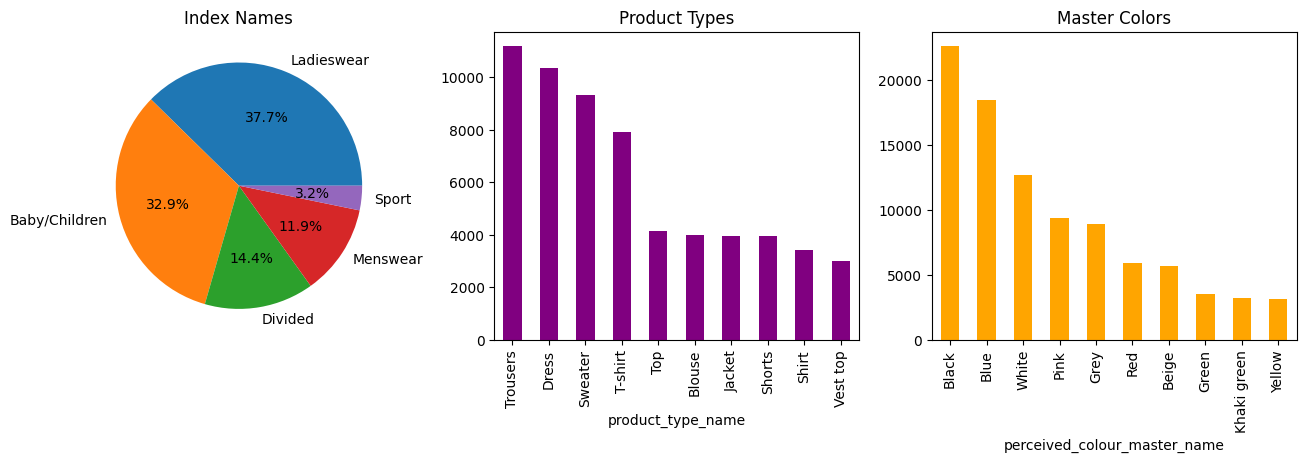

In [61]:
plt.figure(figsize=(16, 4))
plt.subplot(131).set_title('Index Names')
articles['index_group_name'].value_counts().plot.pie(autopct='%1.1f%%', ylabel='')
plt.subplot(132).set_title('Product Types')
articles['product_type_name'].value_counts().head(10).plot.bar(color='purple')
plt.subplot(133).set_title('Master Colors')
articles['perceived_colour_master_name'].value_counts().head(10).plot.bar(color='orange');

C:\Users\admin\AppData\Local\Temp\ipykernel_16072\2509442790.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_genres.values, y=top_10_genres.index, palette="mako")


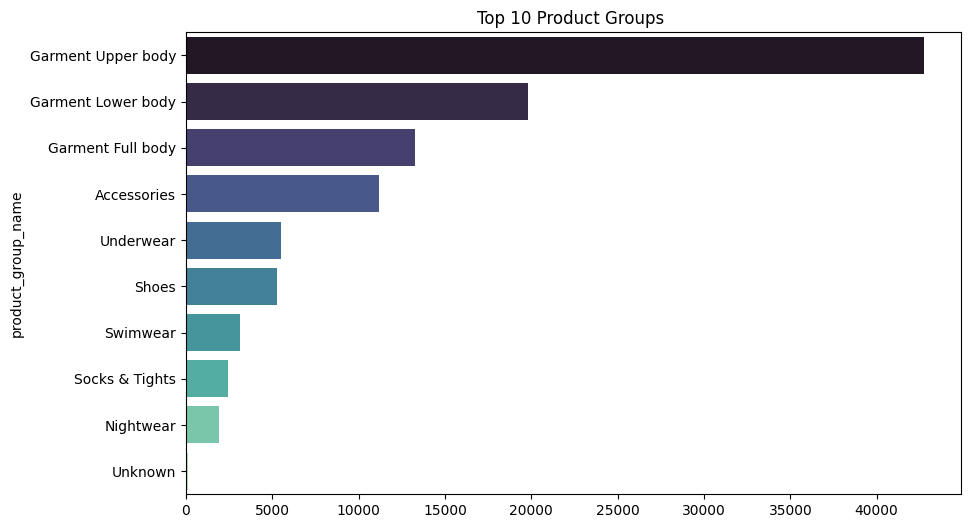

In [62]:
top_10_genres = articles.groupby('product_group_name')['product_type_name'].count().sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 6))
sns.barplot(x=top_10_genres.values, y=top_10_genres.index, palette="mako")
plt.title("Top 10 Product Groups ");

C:\Users\admin\AppData\Local\Temp\ipykernel_16072\2662256435.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=data.index, y=data.values, palette="Set2")


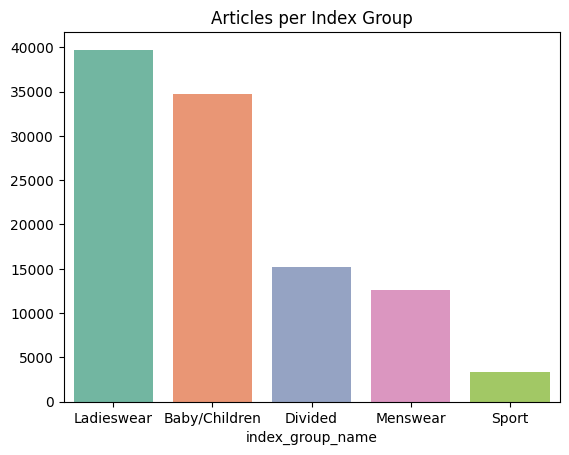

In [63]:
data = articles.groupby("index_group_name")["article_id"].nunique().sort_values(ascending=False)
sns.barplot(x=data.index, y=data.values, palette="Set2")
plt.title('Articles per Index Group');

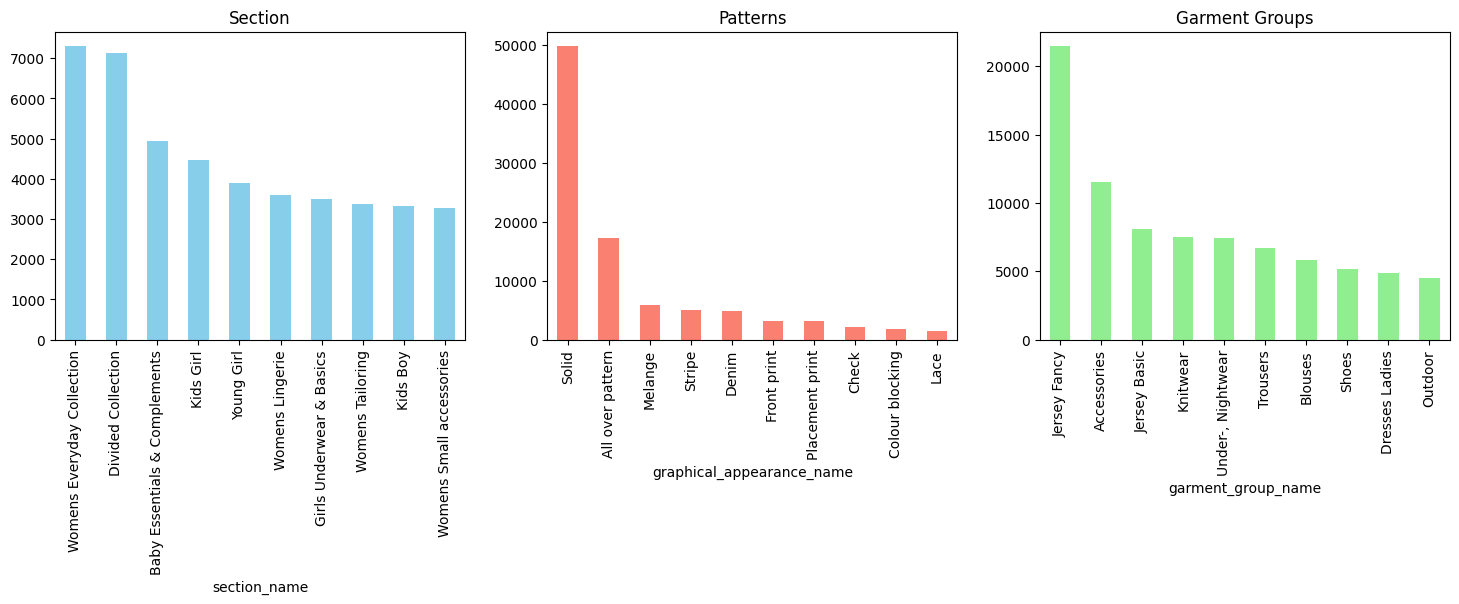

In [64]:
plt.figure(figsize=(18, 4))
plt.subplot(1, 3, 1)
articles['section_name'].value_counts().head(10).plot.bar(title='Section', color='skyblue')
plt.subplot(1, 3, 2)
articles['graphical_appearance_name'].value_counts().head(10).plot.bar(title='Patterns', color='salmon')
plt.subplot(1, 3, 3)
articles['garment_group_name'].value_counts().head(10).plot.bar(title='Garment Groups', color='lightgreen');


The visualizations reveal that the dataset is heavily dominated by upper body garments, indicating that items such as T-shirts, shirts, and tops form the core of the product catalog. There is a clear imbalance across product categories, with groups like Accessories, Shoes, and Underwear having moderate representation, while categories such as Nightwear and Socks & Tights appear significantly less frequent. In terms of index groups, Ladieswear and Baby/Children account for the majority of products, suggesting a strong business focus on these customer segments, whereas Sport remains a relatively small niche. At the section level, collections like Womens Everyday Collection and Divided Collection are the most prominent, further reinforcing the dominance of women's fashion. Additionally, the graphical appearance analysis shows that solid patterns overwhelmingly dominate the dataset, highlighting a preference for simple and minimalist designs, while more complex patterns are less common. Overall, these patterns indicate a highly skewed dataset toward women's everyday fashion, which may introduce bias in modeling and should be carefully considered in downstream tasks such as recommendation systems or predictive modeling.

C:\Users\admin\AppData\Local\Temp\ipykernel_16072\4187227293.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_depts.index, y=top_depts.values, palette="pastel")


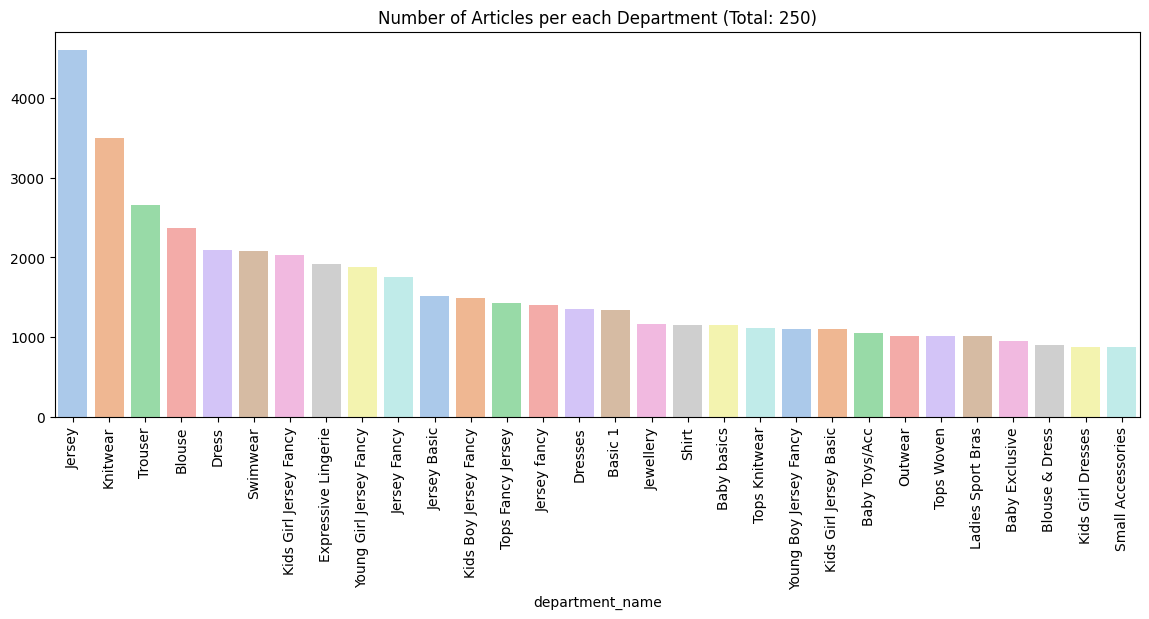

In [65]:
top_depts = articles.groupby("department_name")["article_id"].nunique().sort_values(ascending=False).head(30)
plt.figure(figsize=(14, 5))
sns.barplot(x=top_depts.index, y=top_depts.values, palette="pastel")
plt.title(f'Number of Articles per each Department (Total: {articles["department_name"].nunique()})')
plt.xticks(rotation=90);

In [66]:
articles.isnull().sum()

article_id                        0
product_code                      0
prod_name                         0
product_type_no                   0
product_type_name                 0
product_group_name                0
graphical_appearance_no           0
graphical_appearance_name         0
colour_group_code                 0
colour_group_name                 0
perceived_colour_value_id         0
perceived_colour_value_name       0
perceived_colour_master_id        0
perceived_colour_master_name      0
department_no                     0
department_name                   0
index_code                        0
index_name                        0
index_group_no                    0
index_group_name                  0
section_no                        0
section_name                      0
garment_group_no                  0
garment_group_name                0
detail_desc                     416
dtype: int64

In [67]:
articles['detail_desc'] = articles['detail_desc'].fillna('Unknown')

In [68]:
articles.head()

,article_id,product_code,prod_name,product_type_no,product_type_name,product_group_name,graphical_appearance_no,graphical_appearance_name,colour_group_code,colour_group_name,...,department_name,index_code,index_name,index_group_no,index_group_name,section_no,section_name,garment_group_no,garment_group_name,detail_desc
0,108775015,108775,Strap top,253,Vest top,Garment Upper body,1010016,Solid,9,Black,...,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
1,108775044,108775,Strap top,253,Vest top,Garment Upper body,1010016,Solid,10,White,...,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
2,108775051,108775,Strap top (1),253,Vest top,Garment Upper body,1010017,Stripe,11,Off White,...,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
3,110065001,110065,OP T-shirt (Idro),306,Bra,Underwear,1010016,Solid,9,Black,...,Clean Lingerie,B,Lingeries/Tights,1,Ladieswear,61,Womens Lingerie,1017,"Under-, Nightwear","Microfibre T-shirt bra with underwired, moulde..."
4,110065002,110065,OP T-shirt (Idro),306,Bra,Underwear,1010016,Solid,10,White,...,Clean Lingerie,B,Lingeries/Tights,1,Ladieswear,61,Womens Lingerie,1017,"Under-, Nightwear","Microfibre T-shirt bra with underwired, moulde..."


#### transactions.csv

In [69]:
transactions.head()

,t_dat,customer_id,article_id,price,sales_channel_id
0,2020-08-21,001c2513c498432fdff9eb09349ddf02d31826b148a8c9...,800691007,0.011847,1
1,2020-08-21,001c2513c498432fdff9eb09349ddf02d31826b148a8c9...,841182001,0.016932,1
2,2020-08-21,001c2513c498432fdff9eb09349ddf02d31826b148a8c9...,624443037,0.016932,1
3,2020-08-21,001c2513c498432fdff9eb09349ddf02d31826b148a8c9...,861600003,0.050831,1
4,2020-08-21,001c2513c498432fdff9eb09349ddf02d31826b148a8c9...,815579001,0.030492,1


In [70]:
transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1224824 entries, 0 to 1224823
Data columns (total 5 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   t_dat             1224824 non-null  object 
 1   customer_id       1224824 non-null  object 
 2   article_id        1224824 non-null  int64  
 3   price             1224824 non-null  float64
 4   sales_channel_id  1224824 non-null  int64  
dtypes: float64(1), int64(2), object(2)
memory usage: 46.7+ MB


In [71]:
transactions.isnull().sum()

t_dat               0
customer_id         0
article_id          0
price               0
sales_channel_id    0
dtype: int64

The transactions dataset captures user purchase behavior over time. It includes `t_dat`, `customer_id`, `article_id`,`sales_channel_id` and `price`.

- `t_dat` is a timestamp column that enables time-based analysis such as seasonality, recency, and trend detection.
- `customer_id` and `article_id` are foreign keys linking to customers and articles datasets.
- `price` is a numerical feature representing the transaction value, scaled down by a factor of 1000. It can be transformed back to the original value (in SEK) if needed.
- This dataset is the core of the system, enabling analysis of purchasing patterns and user-item interactions.

Overall, the transactions data is critical for building recommendation systems, especially collaborative filtering and sequential models.

In [72]:
transactions['price_original(SEK)'] = transactions['price'] * 1000

In [73]:
transactions['t_dat'] = pd.to_datetime(transactions['t_dat'])
train = transactions